In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training data shape:", x_train.shape) cxxxxxxxxxx
print("Testing data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2069s 12us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


In [3]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)
print("Labels:", y_train.shape)

Training data: (50000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)
Labels: (50000, 10)


In [4]:
EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.001

print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)

Epochs: 5
Batch Size: 32
Learning Rate: 0.001


In [5]:
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [6]:
def create_lenet5():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(6, (5, 5), activation="tanh", padding="same"),
        layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Conv2D(16, (5, 5), activation="tanh"),
        layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(120, activation="tanh"),
        layers.Dense(84, activation="tanh"),
        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


lenet = create_lenet5()

lenet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
start_time = time.time()

history_lenet = lenet.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

lenet_time = time.time() - start_time

lenet_loss, lenet_accuracy = lenet.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("LeNet-5 Test Accuracy:", lenet_accuracy)
print("LeNet-5 Training Time:", lenet_time, "seconds")
print("LeNet-5 Parameters:", lenet.count_params())

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.3783 - loss: 1.7584 - val_accuracy: 0.4373 - val_loss: 1.5848
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4651 - loss: 1.5129 - val_accuracy: 0.4982 - val_loss: 1.4291
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5097 - loss: 1.3893 - val_accuracy: 0.5124 - val_loss: 1.3762
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5376 - loss: 1.3117 - val_accuracy: 0.5188 - val_loss: 1.3548
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5570 - loss: 1.2546 - val_accuracy: 0.5299 - val_loss: 1.3365
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5299 - loss: 1.3365
LeNet-5 Test Accuracy: 0.5299000144004822
LeNet-5 Training Time: 37.83180069923401 seconds
LeNet-5 Parameters: 83126


In [8]:
def create_alexnet():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(96, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(384, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(384, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(4096, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(4096, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


alexnet = create_alexnet()

alexnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,926,730 (140.86 MB)

 Trainable params: 36,926,026 (140.86 MB)

 Non-trainable params: 704 (2.75 KB)

In [9]:
start_time = time.time()

history_alexnet = alexnet.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

alexnet_time = time.time() - start_time

alexnet_loss, alexnet_accuracy = alexnet.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("AlexNet Test Accuracy:", alexnet_accuracy)
print("AlexNet Training Time:", alexnet_time, "seconds")
print("AlexNet Parameters:", alexnet.count_params())

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.3334 - loss: 1.8046 - val_accuracy: 0.4046 - val_loss: 1.6232
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.4923 - loss: 1.4060 - val_accuracy: 0.5277 - val_loss: 1.2953
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5615 - loss: 1.2449 - val_accuracy: 0.5279 - val_loss: 1.3636
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.5902 - loss: 1.1628 - val_accuracy: 0.5992 - val_loss: 1.1386
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6149 - loss: 1.0987 - val_accuracy: 0.5995 - val_loss: 1.1318
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5995 - loss: 1.1318
AlexNet Test Accuracy: 0.5995000004768372
AlexNet Training Time: 191.14515590667725 seconds
AlexNet Parameters: 36926730


In [10]:
def create_vgg16():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Block 1
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 4
        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 5
        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(512, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


vgg16 = create_vgg16()

vgg16.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,245,130 (58.16 MB)

 Trainable params: 15,245,130 (58.16 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
start_time = time.time()

history_vgg16 = vgg16.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

vgg16_time = time.time() - start_time

vgg16_loss, vgg16_accuracy = vgg16.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("VGG16 Test Accuracy:", vgg16_accuracy)
print("VGG16 Training Time:", vgg16_time, "seconds")
print("VGG16 Parameters:", vgg16.count_params())

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 58ms/step - accuracy: 0.1000 - loss: 2.3037 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.0997 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.0977 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.0991 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.1007 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3027
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1000 - loss: 2.3027
VGG16 Test Accuracy: 0.10000000149011612
VGG16 Training Time: 421.10706853866577 seconds
VGG16 Parameters: 15245130


In [12]:
def inception_module(x, filters):
    f1, f3, f5, fp = filters

    # 1x1 convolution
    branch1 = layers.Conv2D(
        f1, (1, 1), padding="same", activation="relu"
    )(x)

    # 1x1 -> 3x3
    branch2 = layers.Conv2D(
        f3, (1, 1), padding="same", activation="relu"
    )(x)
    branch2 = layers.Conv2D(
        f3, (3, 3), padding="same", activation="relu"
    )(branch2)

    # 1x1 -> 5x5
    branch3 = layers.Conv2D(
        f5, (1, 1), padding="same", activation="relu"
    )(x)
    branch3 = layers.Conv2D(
        f5, (5, 5), padding="same", activation="relu"
    )(branch3)

    # Pooling -> 1x1
    branch4 = layers.MaxPooling2D(
        (3, 3), strides=(1, 1), padding="same"
    )(x)
    branch4 = layers.Conv2D(
        fp, (1, 1), padding="same", activation="relu"
    )(branch4)

    return layers.Concatenate()([
        branch1,
        branch2,
        branch3,
        branch4
    ])

In [13]:
def create_googlenet():
    inputs = layers.Input(shape=(32, 32, 3))

    x = layers.Conv2D(
        64, (3, 3), padding="same", activation="relu"
    )(inputs)

    x = inception_module(x, (32, 32, 16, 16))
    x = inception_module(x, (64, 64, 32, 32))

    x = layers.MaxPooling2D((2, 2))(x)

    x = inception_module(x, (64, 64, 32, 32))
    x = inception_module(x, (128, 128, 64, 64))

    x = layers.MaxPooling2D((2, 2))(x)

    x = inception_module(x, (128, 128, 64, 64))

    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(
        10, activation="softmax"
    )(x)

    model = models.Model(inputs, outputs)

    return compile_model(model)


googlenet = create_googlenet()

googlenet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │      2,080 │ conv2d_20[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │      1,040 │ conv2d_20[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 32, 32,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │      2,080 │ conv2d_20[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_22[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │      6,416 │ conv2d_24[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │      1,040 │ max_pooling2d_8[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_21[0][0],  │
│ (Concatenate)       │ 96)               │            │ conv2d_23[0][0],  │
│                     │                   │            │ conv2d_25[0][0],  │
│                     │                   │            │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │      6,208 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 32, 32,    │      3,104 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 32, 32,    │      6,208 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_28[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 32, 32,    │     25,632 │ conv2d_30[0][0]   │
│                     │ 32)               │            │                 

 Total params: 930,394 (3.55 MB)

 Trainable params: 930,394 (3.55 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
start_time = time.time()

history_googlenet = googlenet.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

googlenet_time = time.time() - start_time

googlenet_loss, googlenet_accuracy = googlenet.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("GoogleNet Test Accuracy:", googlenet_accuracy)
print("GoogleNet Training Time:", googlenet_time, "seconds")
print("GoogleNet Parameters:", googlenet.count_params())

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 38ms/step - accuracy: 0.4030 - loss: 1.5760 - val_accuracy: 0.5636 - val_loss: 1.1890
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.6151 - loss: 1.0606 - val_accuracy: 0.6705 - val_loss: 0.9235
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.7074 - loss: 0.8269 - val_accuracy: 0.7186 - val_loss: 0.8041
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.7605 - loss: 0.6804 - val_accuracy: 0.7441 - val_loss: 0.7453
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.7981 - loss: 0.5748 - val_accuracy: 0.7819 - val_loss: 0.6651
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7819 - loss: 0.6651
GoogleNet Test Accuracy: 0.7818999886512756
GoogleNet Training Time: 262.0007412433624 seconds
GoogleNet Parameters: 930394


In [15]:
def create_resnet50():
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights=None,
        input_shape=(32, 32, 3)
    )

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(
        10,
        activation="softmax"
    )(x)

    model = models.Model(
        inputs=base_model.input,
        outputs=outputs
    )

    return compile_model(model)


resnet50 = create_resnet50()

resnet50.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 23,555,082 (89.86 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [16]:
start_time = time.time()

history_resnet50 = resnet50.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)

resnet50_time = time.time() - start_time

resnet50_loss, resnet50_accuracy = resnet50.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("ResNet50 Test Accuracy:", resnet50_accuracy)
print("ResNet50 Training Time:", resnet50_time, "seconds")
print("ResNet50 Parameters:", resnet50.count_params())

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 119s 46ms/step - accuracy: 0.3331 - loss: 2.1651 - val_accuracy: 0.1228 - val_loss: 109.6224
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.2448 - loss: 2.3675 - val_accuracy: 0.1946 - val_loss: 3.6656
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.3187 - loss: 2.0469 - val_accuracy: 0.3635 - val_loss: 1.9513
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.4026 - loss: 1.8441 - val_accuracy: 0.3920 - val_loss: 5.3815
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.4156 - loss: 1.7798 - val_accuracy: 0.4345 - val_loss: 3.7592
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4345 - loss: 3.7592
ResNet50 Test Accuracy: 0.4345000088214874
ResNet50 Training Time: 299.1278703212738 seconds
ResNet50 Parameters: 23608202


In [17]:
results = pd.DataFrame({
    "Architecture": [
        "LeNet-5",
        "AlexNet",
        "VGG16",
        "GoogleNet",
        "ResNet50"
    ],

    "Parameters": [
        lenet.count_params(),
        alexnet.count_params(),
        vgg16.count_params(),
        googlenet.count_params(),
        resnet50.count_params()
    ],

    "Test Accuracy (%)": [
        lenet_accuracy * 100,
        alexnet_accuracy * 100,
        vgg16_accuracy * 100,
        googlenet_accuracy * 100,
        resnet50_accuracy * 100
    ],

    "Training Time (seconds)": [
        lenet_time,
        alexnet_time,
        vgg16_time,
        googlenet_time,
        resnet50_time
    ]
})

results

,Architecture,Parameters,Test Accuracy (%),Training Time (seconds)
0,LeNet-5,83126,52.990001,37.831801
1,AlexNet,36926730,59.950000,191.145156
2,VGG16,15245130,10.000000,421.107069
3,GoogleNet,930394,78.189999,262.000741
4,ResNet50,23608202,43.450001,299.127870


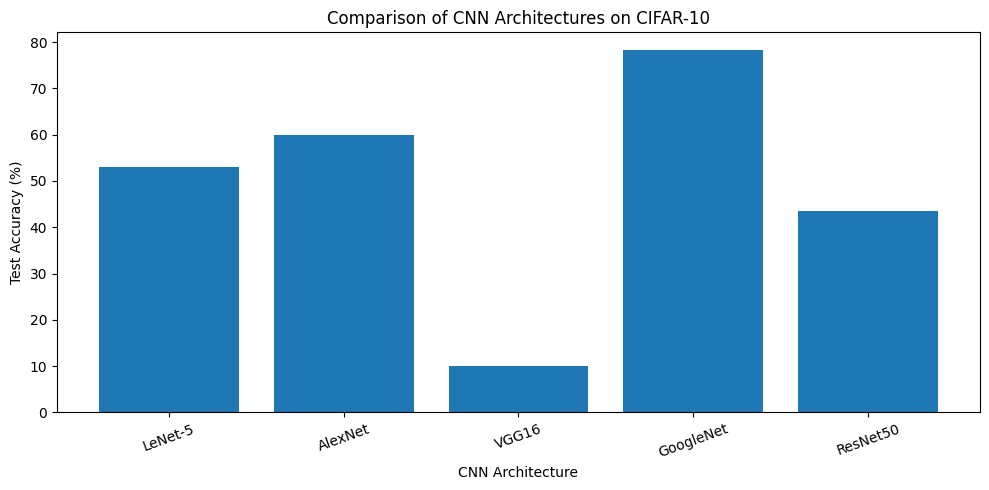

In [18]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Architecture"],
    results["Test Accuracy (%)"]
)

plt.xlabel("CNN Architecture")
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of CNN Architectures on CIFAR-10")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

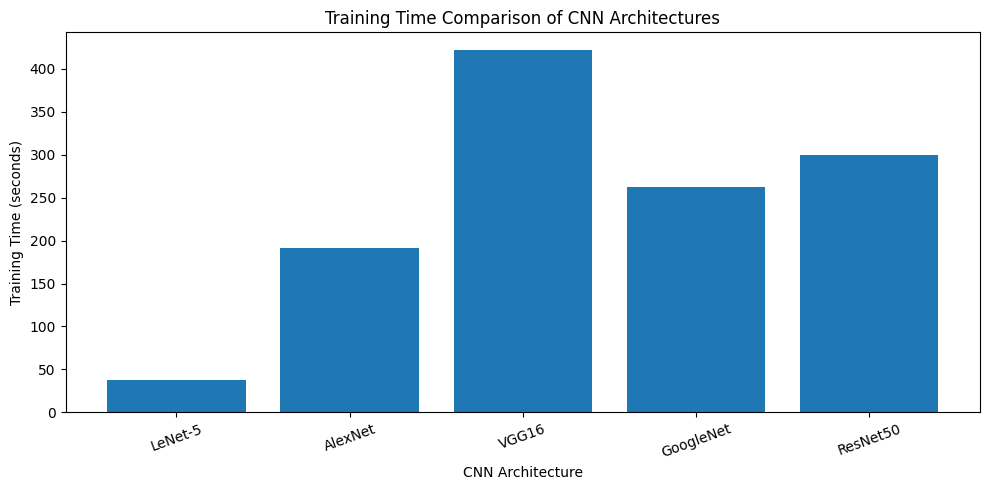

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Architecture"],
    results["Training Time (seconds)"]
)

plt.xlabel("CNN Architecture")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison of CNN Architectures")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()